# K-means Clustering on Non-Linear Moon-Shaped Data

This notebook demonstrates a limitation of K-means clustering when applied to
non-linearly separable data. Using the `make_moons` dataset, it shows how
K-means fails to properly separate two interleaved crescent-shaped clusters.

The synthetic dataset consists of 200 points arranged in two moon shapes
with a noise level of 0.05.

## Generate Moon-Shaped Data

`make_moons` creates two interleaved half-circles. Unlike blobs, these clusters
are not linearly separable, which poses a challenge for distance-based algorithms like K-means.

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# Generate moon-shaped data
X, Y = make_moons(n_samples=200,    # Total number of points
                 noise=0.05,        # Amount of noise/spread
                 random_state=0)    # For reproducibility

## Attempt K-means Clustering

K-means is initialised with 2 clusters to match the two moon shapes.
Because K-means partitions space with linear (Voronoi) boundaries, it cannot
follow the curved structure of the moons.

In [2]:
# Attempt K-means clustering
kmeans = KMeans(n_clusters=2)  # Initialize with 2 clusters
kmeans.fit(X)                  # Fit model to data
y_kmeans = kmeans.labels_      # Get cluster assignments

## Visualise Results

The colouring reveals that K-means splits the data vertically rather than
following the moon shapes, demonstrating its inability to handle non-convex clusters.

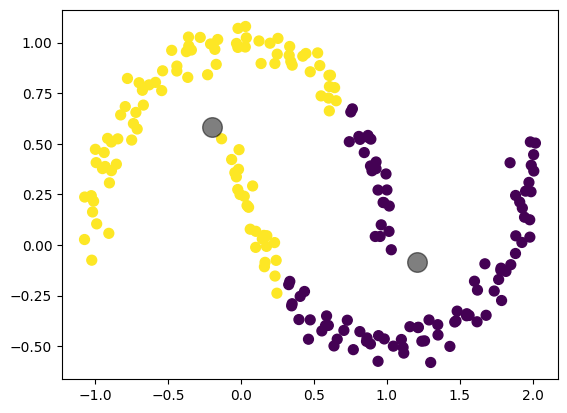

In [3]:
# Visualize results
plt.scatter(X[:, 0], X[:, 1],     # Plot data points
          c=y_kmeans,             # Color by cluster assignment
          s=50,                   # Point size
          cmap='viridis')         # Color scheme

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],  # Plot centers
          c='black',                      # Center color
          s=200,                          # Center point size
          alpha=0.5)                      # Transparency
plt.show()